In [1]:
import pandas as pd

# data = pd.read_csv("performance.csv")
data = pd.read_csv("selected_memory.csv")
#data = data.drop("amp", axis=1).drop("info", axis=1)
data = data.rename(columns={
    "Model": "model",
    "latency(s)": "latency",
    "memory(m)": "memory",
    "cpu time(ms)": "cpu_time",
    "gpu time(ms)": "gpu_time"
})
data = data.dropna(subset=["model"]).fillna(0)

method_names = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
model_names = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]

def rename_models(data):
    old = ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"]
    new = ["ResNet32ori", "ResNet110", "ResNet32", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]
    for o, n in zip(old, new):
        data.loc[data.model == o, "model"] = n
        
def rename_methods(data):
    old = ["base", "manual", "reversify", "checkpoint"]
    new = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
    for o, n in zip(old, new):
        data.loc[data.method == o, "method"] = n
    
for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    data.loc[data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"],
    model_names
):
    data.loc[data.model == old, "model"] = new
    
memory = data

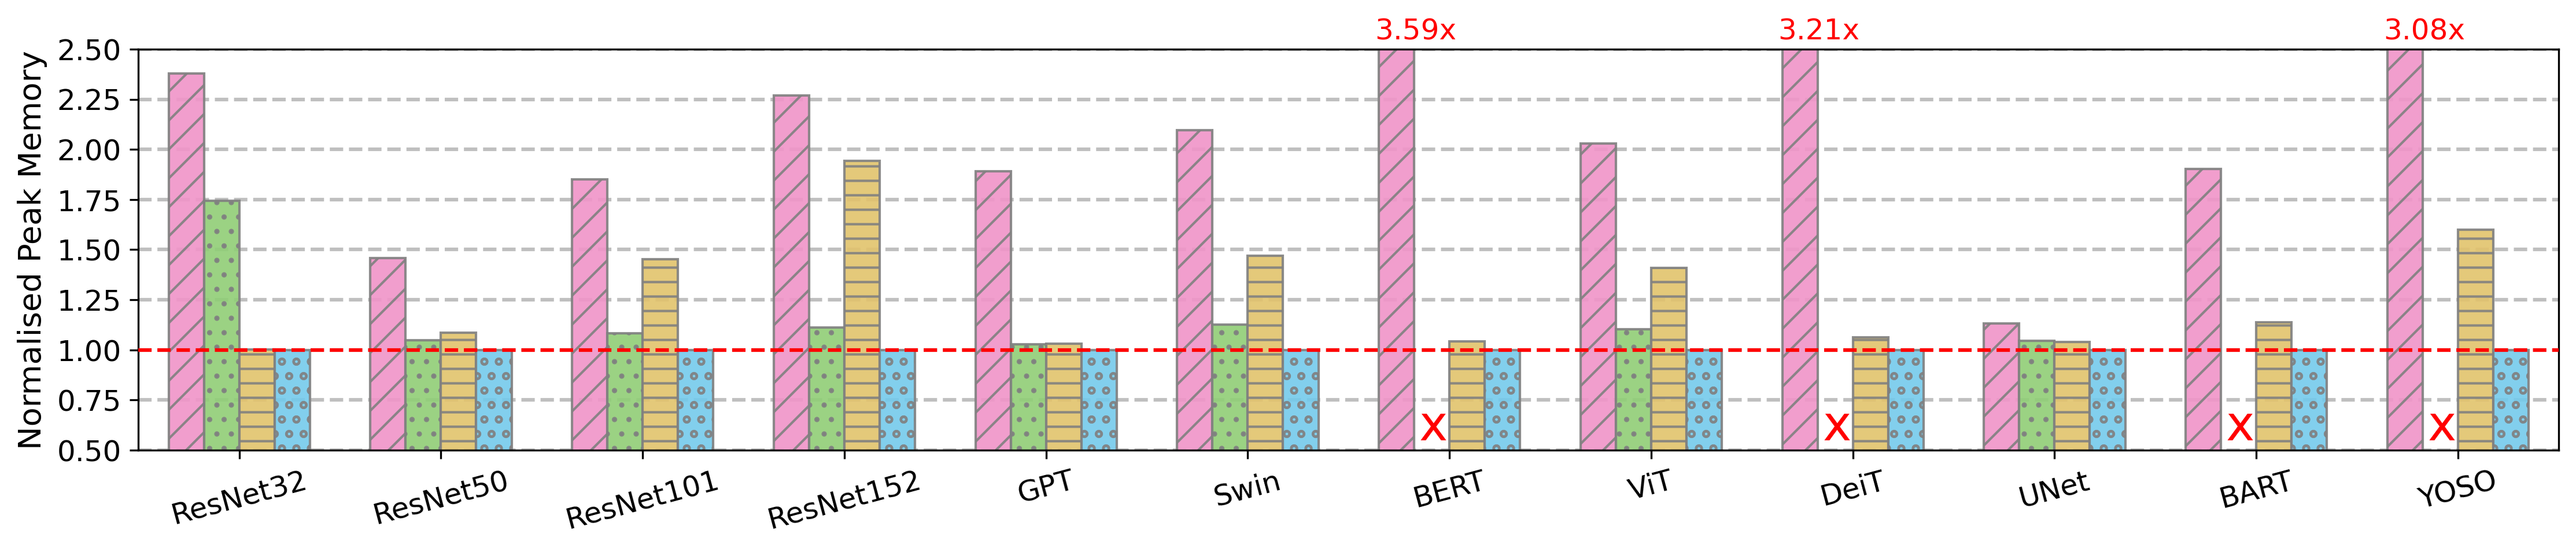

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "..", "--", "oo"]

plt.rcParams["figure.figsize"] = (18, 3)
ax = sns.barplot(memory, x="model", y="ratio", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.9, width=0.7)
ax.axhline(y=1.0, color='r', linestyle='--', zorder=11)
ax.get_legend().remove()
plt.xlabel(None)
plt.ylabel("Normalised Peak Memory", fontsize=13)
#plt.legend(None)
#legend = plt.legend(loc="upper center", bbox_to_anchor=(0.185, 1.22), ncols=4, frameon=False, fontsize=12)

#for patch, hatch in zip(legend.get_patches(), hatches):
#    patch.set_hatch(hatch)
#    patch.set_edgecolor("gray")

plt.xticks(rotation=15, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.5, 2.5)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")
    
# manual
manual_indices = [12, 14, 16, 17]
for index in manual_indices:
    bar = ax.patches[index+6]
    plt.text(bar.get_x() + 0.025, 0.55, "x", color="red", fontsize=20)

# bert
bar = ax.patches[6]
plt.text(bar.get_x() - 0.02, 2.55, f'{memory[(memory.model == "BERT") & (memory.method == "Original")].ratio.item():.2f}x', color="red", fontsize=12)

# diet
bar = ax.patches[8]
plt.text(bar.get_x() - 0.02, 2.55, f'{memory[(memory.model == "DeiT") & (memory.method == "Original")].ratio.item():.2f}x', color="red", fontsize=12)

# bart
bar = ax.patches[11]
plt.text(bar.get_x() - 0.02, 2.55, f'{memory[(memory.model == "YOSO") & (memory.method == "Original")].ratio.item():.2f}x', color="red", fontsize=12)

for y in [0.25 * i for i in range(2, 12)]:
    ax.axhline(y=y, color="gray", linestyle="--", zorder=0, alpha=0.5)

plt.savefig("memory-final.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)